In [17]:
# Importing required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [18]:
# Loading the feature-engineered dataset
data=pd.read_csv("../data/model_ready_data.csv")
data.head()

,Country Name,year,temp_anomaly,lag_1,rolling_mean_5,decade,country_encoded
0,"Afghanistan, Islamic Rep. of",1971,0.652,0.898,0.775000,1970,0
1,"Afghanistan, Islamic Rep. of",1972,-1.089,0.652,0.153667,1970,0
2,"Afghanistan, Islamic Rep. of",1973,0.262,-1.089,0.180750,1970,0
3,"Afghanistan, Islamic Rep. of",1974,-0.470,0.262,0.050600,1970,0
4,"Afghanistan, Islamic Rep. of",1975,-0.468,-0.470,-0.222600,1970,0


In [19]:
# Defining input features and the target variable
features=["year","lag_1","rolling_mean_5","decade","country_encoded"]
target="temp_anomaly"

X=data[features]
y=data[target]

In [20]:
# Splitting by year instead of randomly so that this mimics the real forecasting
train_data=data[data["year"]<=2015]
test_data=data[data["year"]>2015]

X_train=train_data[features]
y_train=train_data[target]
X_test=test_data[features]
y_test=test_data[target]

In [21]:
# Creating and training the XGBoost regression model
model = xgb.XGBRegressor(n_estimators=100,learning_rate=0.1,max_depth=4,random_state=42)
model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [22]:
# Predicting temperature change for every country from 2022 to 2050, one year at a time
future_years=list(range(2022, 2051))
results=[]

for country in data["Country Name"].unique():
    country_data=data[data["Country Name"]==country].sort_values("year")
    country_code=country_data["country_encoded"].iloc[0]

    # Starting with the real known history for this country
    history=country_data["temp_anomaly"].tolist()

    row_result={"Country":country}

    for year in future_years:
        # Using the most recent value (real or predicted) as lag_1
        lag_1=history[-1]
        rolling_mean_5=np.mean(history[-5:])
        decade=(year//10)*10

        input_row=pd.DataFrame([{
            "year":year,
            "lag_1":lag_1,
            "rolling_mean_5":rolling_mean_5,
            "decade":decade,
            "country_encoded":country_code
        }])
        pred=model.predict(input_row)[0]
        row_result[str(year)]=pred
        history.append(pred)  # feeding this prediction into the next year's lag

    results.append(row_result)
pred_data=pd.DataFrame(results)
pred_data.head()

,Country,2022,2023,2024,2025,2026,2027,2028,2029,2030,...,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050
0,"Afghanistan, Islamic Rep. of",1.287824,1.303954,1.083292,1.313864,1.334627,1.320657,1.334627,1.334627,1.496528,...,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189
1,Albania,1.799750,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189,...,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189
2,Algeria,1.917495,1.820552,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189,...,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189
3,American Samoa,0.968631,0.954745,1.006545,1.072174,1.072174,1.147044,1.210399,1.100366,1.269022,...,1.735632,1.775388,1.799750,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189
4,"Andorra, Principality of",1.767562,1.804373,1.813812,1.813812,1.813812,1.813812,1.813812,1.813812,1.813812,...,1.813812,1.813812,1.813812,1.813812,1.813812,1.813812,1.813812,1.813812,1.813812,1.813812


In [23]:
pred_data 

,Country,2022,2023,2024,2025,2026,2027,2028,2029,2030,...,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050
0,"Afghanistan, Islamic Rep. of",1.287824,1.303954,1.083292,1.313864,1.334627,1.320657,1.334627,1.334627,1.496528,...,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189
1,Albania,1.799750,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189,...,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189
2,Algeria,1.917495,1.820552,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189,...,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189
3,American Samoa,0.968631,0.954745,1.006545,1.072174,1.072174,1.147044,1.210399,1.100366,1.269022,...,1.735632,1.775388,1.799750,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189,1.809189
4,"Andorra, Principality of",1.767562,1.804373,1.813812,1.813812,1.813812,1.813812,1.813812,1.813812,1.813812,...,1.813812,1.813812,1.813812,1.813812,1.813812,1.813812,1.813812,1.813812,1.813812,1.813812
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222,Western Sahara,1.872623,1.837403,1.935755,1.947119,1.947119,1.947119,1.947119,1.947119,1.947119,...,1.947119,1.947119,1.947119,1.947119,1.947119,1.947119,1.947119,1.947119,1.947119,1.947119
223,World,1.646272,1.755563,1.872623,1.947119,1.947119,1.947119,1.947119,1.947119,1.947119,...,1.947119,1.947119,1.947119,1.947119,1.947119,1.947119,1.947119,1.947119,1.947119,1.947119
224,"Yemen, Rep. of",0.064221,0.064221,0.064221,0.064221,0.064221,0.064221,0.064221,0.064221,0.064221,...,0.064221,0.064221,0.064221,0.064221,0.064221,0.064221,0.064221,0.064221,0.064221,0.064221
225,Zambia,1.180074,1.242738,1.340114,1.322915,1.367997,1.419929,1.484852,1.650219,1.650219,...,1.947119,1.947119,1.947119,1.947119,1.947119,1.947119,1.947119,1.947119,1.947119,1.947119


In [24]:
# Making predictions on the test set and checking accuracy
predictions=model.predict(X_test)

mae=mean_absolute_error(y_test, predictions)
r2=r2_score(y_test, predictions)

print("Mean Absolute Error:",mae)
print("R² Score:",r2)

Mean Absolute Error: 0.26797990847154685
R² Score: 0.6076489782847252


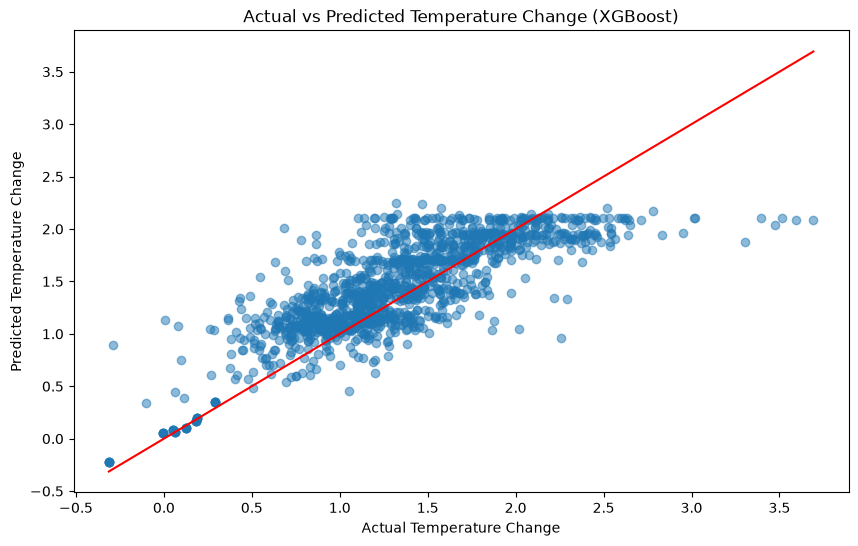

In [25]:
# Comparing actual vs predicted temperature change values
plt.figure(figsize=(10,6))
plt.scatter(y_test, predictions,alpha=0.5)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],color="red")
plt.xlabel("Actual Temperature Change")
plt.ylabel("Predicted Temperature Change")
plt.title("Actual vs Predicted Temperature Change (XGBoost)")
plt.show()

In [26]:
# Average predicted temperature per year
mean_per_year=pred_data[[str(y) for y in future_years]].mean()
mean_df=mean_per_year.reset_index()
mean_df.columns=["Year", "Mean_Temp_Change"]
print(mean_df)

    Year  Mean_Temp_Change
0   2022          1.523627
1   2023          1.508992
2   2024          1.580156
3   2025          1.604496
4   2026          1.637416
5   2027          1.693472
6   2028          1.710867
7   2029          1.740541
8   2030          1.766055
9   2031          1.798320
10  2032          1.817959
11  2033          1.837692
12  2034          1.855178
13  2035          1.866472
14  2036          1.871453
15  2037          1.876154
16  2038          1.879376
17  2039          1.881192
18  2040          1.883565
19  2041          1.886462
20  2042          1.888116
21  2043          1.889602
22  2044          1.890533
23  2045          1.892507
24  2046          1.893312
25  2047          1.894179
26  2048          1.894823
27  2049          1.895713
28  2050          1.896403


In [27]:
# Highest predicted country by 2050
max_row=pred_data.loc[pred_data["2050"].idxmax()]
print(max_row["Country"],max_row["2050"])

Saudi Arabia 2.099267


In [28]:
# Lowest predicted country by 2050
min_row=pred_data.loc[pred_data["2050"].idxmin()]
print(min_row["Country"],min_row["2050"])

Yemen, Rep. of 0.06422062


In [31]:
# Countries predicted to exceed 2°C rise by 2050
baseline = data[data["year"]==1971][["Country Name","temp_anomaly"]].rename(columns={"temp_anomaly":"baseline"})
merged=pred_data.merge(baseline,left_on="Country",right_on="Country Name")
merged["rise_2050"]=merged["2050"]-merged["baseline"]
countries_over_2_2050=merged[merged["rise_2050"]>2]["Country"]

print("Number of countries with >2°C rise in 2050:",len(countries_over_2_2050))
print(countries_over_2_2050.tolist())

Number of countries with >2°C rise in 2050: 152
['Albania', 'Algeria', 'American Samoa', 'Andorra, Principality of', 'Anguilla', 'Antigua and Barbuda', 'Argentina', 'Armenia, Rep. of', 'Aruba, Kingdom of the Netherlands', 'Azerbaijan, Rep. of', 'Bahrain, Kingdom of', 'Bangladesh', 'Barbados', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Brazil', 'British Virgin Islands', 'Brunei Darussalam', 'Bulgaria', 'Burundi', 'Cambodia', 'Cameroon', 'Cayman Islands', 'Central African Rep.', 'Chad', 'Chile', 'China, P.R.: Hong Kong', 'China, P.R.: Macao', 'Colombia', 'Comoros, Union of the', 'Congo, Dem. Rep. of the', 'Cook Islands', 'Costa Rica', 'Cyprus', 'Djibouti', 'Dominica', 'Dominican Rep.', 'Ecuador', 'Egypt, Arab Rep. of', 'El Salvador', 'Equatorial Guinea, Rep. of', 'Finland', 'France', 'French Polynesia', 'Gabon', 'Gambia, The', 'Georgia', 'Ghana', 'Gibraltar', 'Greece', 'Greenland', 'Grenada', 'Guadeloupe', 'Guatemala', 'Guiana, French', 'Guinea', 'Guinea-Bissau', 'Guyana', 'Holy See', 'Hon

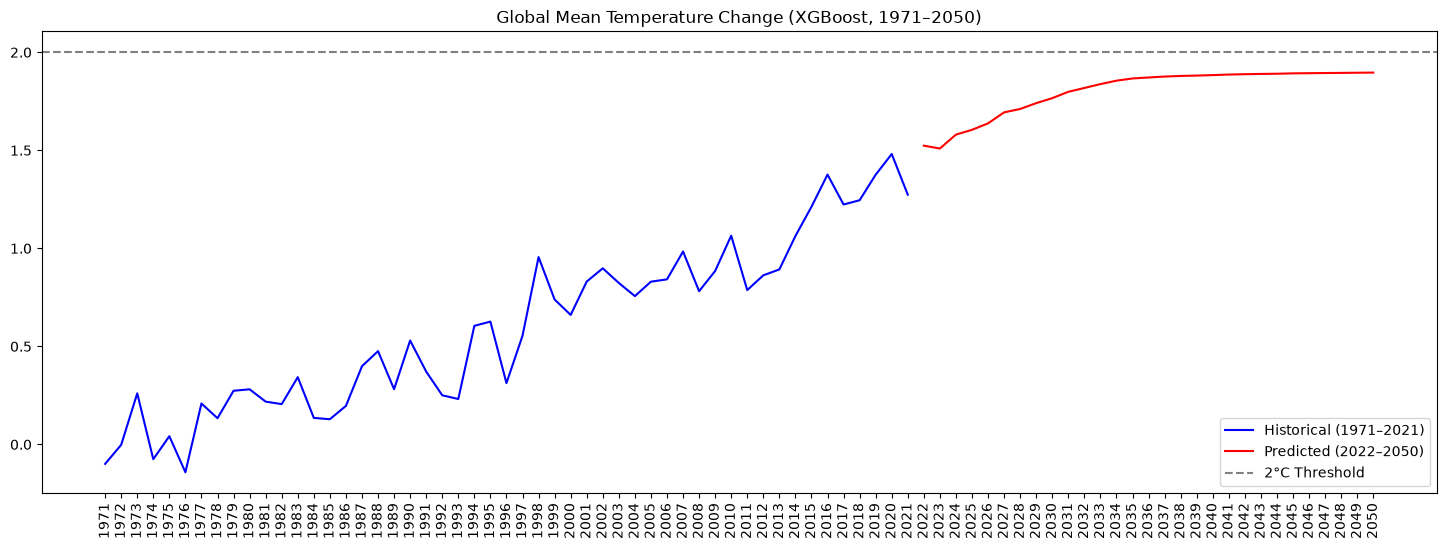

In [30]:
# Historical + predicted line graph, same as before
# Note: year 1970 was dropped earlier so historical data starts from 1971
historical_years=sorted(data["year"].unique())

historical_mean=data.pivot(index="Country Name",columns="year",values="temp_anomaly")[historical_years].mean()
future_mean=pred_data[[str(y) for y in future_years]].mean()

plt.figure(figsize=(18,6))
plt.plot([str(y) for y in historical_years], historical_mean.values, color="blue", label="Historical (1971–2021)")
plt.plot([str(y) for y in future_years], future_mean.values, color="red", label="Predicted (2022–2050)")
plt.axhline(2, color="gray", linestyle="--", label="2°C Threshold")
plt.xticks(rotation=90)
plt.legend()
plt.title("Global Mean Temperature Change (XGBoost, 1971–2050)")
plt.show()